In [2]:
import requests
import pandas as pd

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "A191RL1Q225SBEA",
    "api_key": "4c68fd37456d1706c93321651fd0efa5",
    "file_type": "json"
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    # Convert observations to a DataFrame
    df = pd.DataFrame(data['observations'])
    
    # Clean up the data
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df.set_index('date', inplace=True)
    
    print(df.tail())
else:
    print(f"Error: {response.status_code}, {response.text}")

           realtime_start realtime_end  value
date                                         
2024-10-01     2026-03-13   2026-03-13    1.9
2025-01-01     2026-03-13   2026-03-13   -0.6
2025-04-01     2026-03-13   2026-03-13    3.8
2025-07-01     2026-03-13   2026-03-13    4.4
2025-10-01     2026-03-13   2026-03-13    0.7


In [3]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Prepare the GDP growth series ──────────────────────────────────────────
gdp = df[['value']].copy().dropna()
gdp.index = pd.to_datetime(gdp.index)
gdp = gdp.sort_index()
gdp.rename(columns={'value': 'gdp_growth'}, inplace=True)

print(f"Series length: {len(gdp)} quarters ({gdp.index[0].date()} → {gdp.index[-1].date()})")
gdp.tail()

Series length: 315 quarters (1947-04-01 → 2025-10-01)


,gdp_growth
date,
2024-10-01,1.9
2025-01-01,-0.6
2025-04-01,3.8
2025-07-01,4.4
2025-10-01,0.7


In [4]:
# ── 2. Feature engineering — build up to 20 autoregressive lags ──────────────
MAX_LAGS = 20

for lag in range(1, MAX_LAGS + 1):
    gdp[f'lag_{lag}'] = gdp['gdp_growth'].shift(lag)

gdp.dropna(inplace=True)
target_col = 'gdp_growth'

print(f"Data after dropping NaNs: {len(gdp)} quarters ({gdp.index[0].date()} → {gdp.index[-1].date()})")
gdp[[f'lag_{i}' for i in range(1, 6)]].head()

Data after dropping NaNs: 295 quarters (1952-04-01 → 2025-10-01)


,lag_1,lag_2,lag_3,lag_4,lag_5
date,,,,,
1952-04-01,4.3,0.9,8.5,7.1,5.5
1952-07-01,0.8,4.3,0.9,8.5,7.1
1952-10-01,2.9,0.8,4.3,0.9,8.5
1953-01-01,13.8,2.9,0.8,4.3,0.9
1953-04-01,7.7,13.8,2.9,0.8,4.3


Searching for optimal N_LAGS via 5-fold time-series CV ...

  N_LAGS= 1  |  CV RMSE=4.880
  N_LAGS= 2  |  CV RMSE=4.403
  N_LAGS= 3  |  CV RMSE=4.294
  N_LAGS= 4  |  CV RMSE=4.309
  N_LAGS= 5  |  CV RMSE=4.200
  N_LAGS= 6  |  CV RMSE=4.147
  N_LAGS= 7  |  CV RMSE=4.157
  N_LAGS= 8  |  CV RMSE=4.157
  N_LAGS= 9  |  CV RMSE=4.117
  N_LAGS=10  |  CV RMSE=4.128
  N_LAGS=11  |  CV RMSE=4.129
  N_LAGS=12  |  CV RMSE=4.136
  N_LAGS=13  |  CV RMSE=4.104
  N_LAGS=14  |  CV RMSE=4.111
  N_LAGS=15  |  CV RMSE=4.113
  N_LAGS=16  |  CV RMSE=4.093
  N_LAGS=17  |  CV RMSE=4.165
  N_LAGS=18  |  CV RMSE=4.173
  N_LAGS=19  |  CV RMSE=4.166
  N_LAGS=20  |  CV RMSE=4.123

>>> Optimal N_LAGS = 16  (CV RMSE = 4.093)


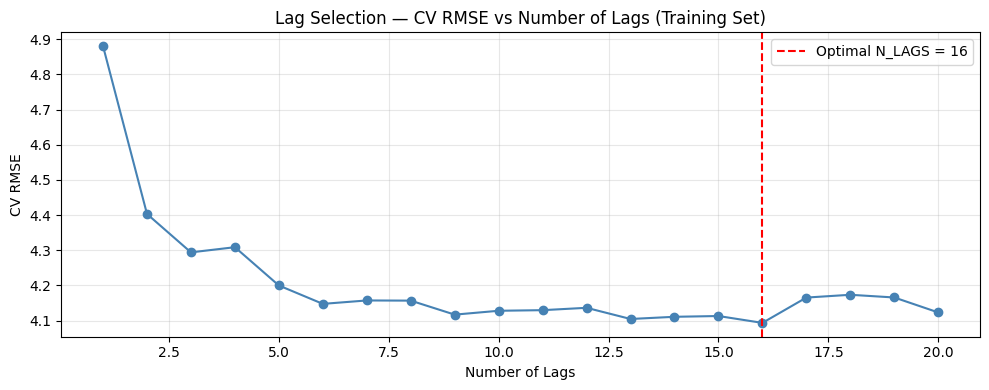


Feature matrix: (295, 16)  |  features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16']
Train: 275 obs  (1952-04-01 → 2020-10-01)
Test : 20  obs  (2021-01-01  → 2025-10-01)
Test share: 6.8%


In [5]:
# ── 3. Train/test split + lag selection via cross-validation ──────────────────
SPLIT_DATE = '2021-01-01'
split_idx  = gdp.index.searchsorted(SPLIT_DATE)

# ── 3a. Lag selection on training data only ───────────────────────────────────
print("Searching for optimal N_LAGS via 5-fold time-series CV ...\n")
lag_cv_rmse = {}

for n in range(1, MAX_LAGS + 1):
    cols_n = [f'lag_{i}' for i in range(1, n + 1)]
    X_n    = gdp[cols_n].values[:split_idx]
    y_n    = gdp[target_col].values[:split_idx]

    fold_rmses = []
    for tr_idx, val_idx in TimeSeriesSplit(n_splits=5).split(X_n):
        rf_tmp = RandomForestRegressor(n_estimators=200, random_state=42)
        rf_tmp.fit(X_n[tr_idx], y_n[tr_idx])
        pred = rf_tmp.predict(X_n[val_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y_n[val_idx], pred)))

    lag_cv_rmse[n] = np.mean(fold_rmses)
    print(f"  N_LAGS={n:2d}  |  CV RMSE={lag_cv_rmse[n]:.3f}")

N_LAGS = min(lag_cv_rmse, key=lag_cv_rmse.get)
print(f"\n>>> Optimal N_LAGS = {N_LAGS}  (CV RMSE = {lag_cv_rmse[N_LAGS]:.3f})")

# Plot CV RMSE vs lag count
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(lag_cv_rmse.keys()), list(lag_cv_rmse.values()), marker='o', color='steelblue')
ax.axvline(N_LAGS, color='red', linestyle='--', label=f'Optimal N_LAGS = {N_LAGS}')
ax.set_xlabel('Number of Lags')
ax.set_ylabel('CV RMSE')
ax.set_title('Lag Selection — CV RMSE vs Number of Lags (Training Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3b. Build final feature matrix with optimal lags ─────────────────────────
feature_cols = [f'lag_{i}' for i in range(1, N_LAGS + 1)]

X = gdp[feature_cols].values
y = gdp[target_col].values

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = gdp.index[:split_idx]
dates_test  = gdp.index[split_idx:]

print(f"\nFeature matrix: {X.shape}  |  features: {feature_cols}")
print(f"Train: {len(X_train)} obs  ({dates_train[0].date()} → {dates_train[-1].date()})")
print(f"Test : {len(X_test)}  obs  ({dates_test[0].date()}  → {dates_test[-1].date()})")
print(f"Test share: {len(X_test)/len(X)*100:.1f}%")

In [6]:
# ── 4. Rolling-window cross-validation on the training set ────────────────────
# TimeSeriesSplit respects temporal order: each fold's test set is always
# strictly after its training set (expanding window).

N_SPLITS = 5   # number of CV folds

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

rf_cv = RandomForestRegressor(n_estimators=200, random_state=42)

cv_rmse, cv_mae = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    rf_cv.fit(X_tr, y_tr)
    y_pred_val = rf_cv.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae  = mean_absolute_error(y_val, y_pred_val)
    cv_rmse.append(rmse)
    cv_mae.append(mae)
    print(f"  Fold {fold}  |  train={len(X_tr):3d}  val={len(X_val):2d}  |  RMSE={rmse:.3f}  MAE={mae:.3f}")

print(f"\nCV mean RMSE : {np.mean(cv_rmse):.3f} ± {np.std(cv_rmse):.3f}")
print(f"CV mean MAE  : {np.mean(cv_mae):.3f} ± {np.std(cv_mae):.3f}")

  Fold 1  |  train= 50  val=45  |  RMSE=4.336  MAE=3.482
  Fold 2  |  train= 95  val=45  |  RMSE=4.180  MAE=3.037
  Fold 3  |  train=140  val=45  |  RMSE=2.026  MAE=1.644
  Fold 4  |  train=185  val=45  |  RMSE=2.818  MAE=2.065
  Fold 5  |  train=230  val=45  |  RMSE=7.106  MAE=3.102

CV mean RMSE : 4.093 ± 1.735
CV mean MAE  : 2.666 ± 0.693


In [7]:
# ── 5. Final model — train on full training set, evaluate on test set ─────────
rf_final = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X_train, y_train)

y_pred_test = rf_final.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)

print("─" * 40)
print(f"Out-of-sample RMSE : {test_rmse:.3f}")
print(f"Out-of-sample MAE  : {test_mae:.3f}")
print("─" * 40)

# Feature importance
importances = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances.to_string())

────────────────────────────────────────
Out-of-sample RMSE : 2.723
Out-of-sample MAE  : 2.299
────────────────────────────────────────

Feature importances:
lag_1     0.351670
lag_2     0.069079
lag_6     0.053508
lag_13    0.051697
lag_5     0.051080
lag_8     0.048446
lag_15    0.044585
lag_11    0.041281
lag_14    0.040932
lag_12    0.040605
lag_3     0.039867
lag_9     0.038437
lag_4     0.035449
lag_10    0.034759
lag_16    0.033219
lag_7     0.025386


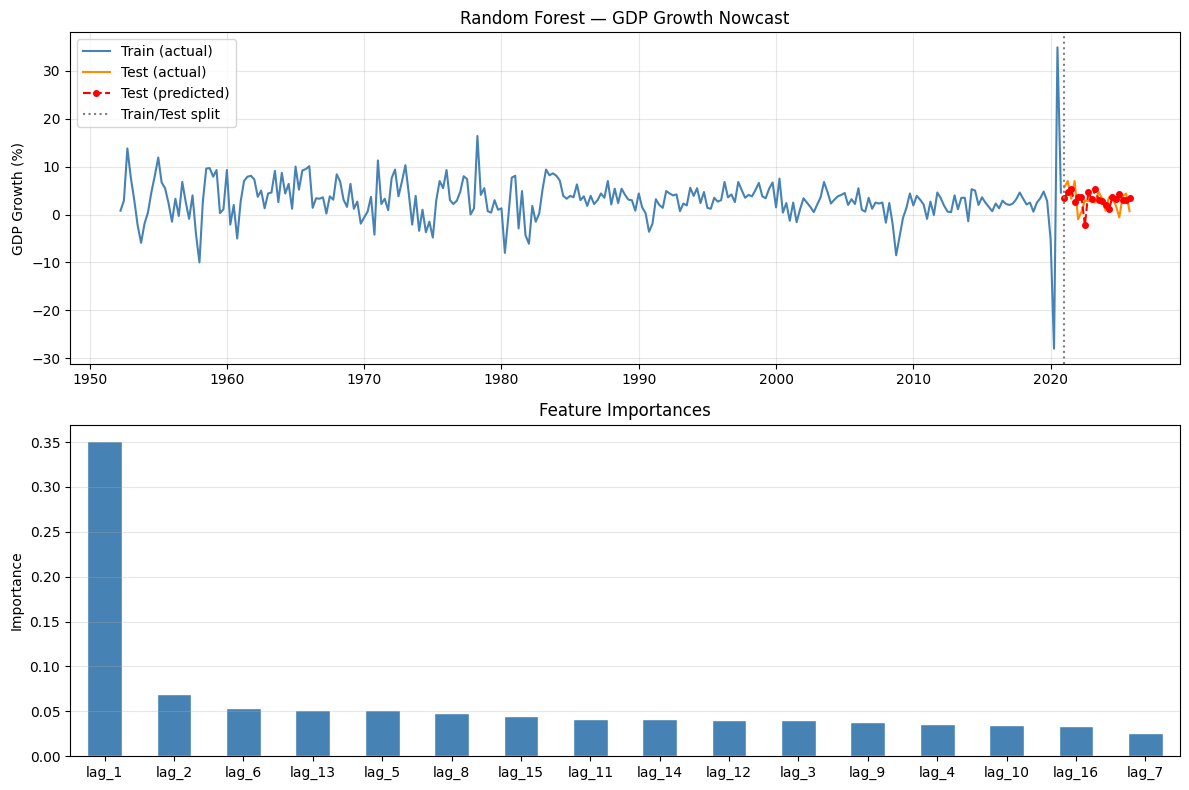

In [8]:
# ── 6. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# (a) Full series with train/test split
ax = axes[0]
ax.plot(dates_train, y_train, label='Train (actual)', color='steelblue')
ax.plot(dates_test,  y_test,  label='Test (actual)',  color='darkorange')
ax.plot(dates_test,  y_pred_test, label='Test (predicted)', color='red', linestyle='--', marker='o', markersize=4)
ax.axvline(dates_test[0], color='grey', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('Random Forest — GDP Growth Nowcast')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Feature importances
ax2 = axes[1]
importances.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Feature Importances')
ax2.set_ylabel('Importance')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Improved Models with COVID Dummies
Two dummies are added to account for the opposing COVID shocks:
- **`covid_crash`** = 1 for 2020 Q2 (GDP ~−28%), else 0
- **`covid_rebound`** = 1 for 2020 Q3 (GDP ~+35%), else 0

> **Note:** To improve the model by including the COVID Dummies, I decrease the size of the testing dataset so that the training dataset can include the COVID data. 

In [9]:
# ── 7. Build COVID-augmented feature matrix ───────────────────────────────────
gdp_covid = gdp.copy()   # gdp already has lag_1..lag_4 from earlier cells

gdp_covid['covid_crash']   = (gdp_covid.index == '2020-04-01').astype(int)  # Q2 2020
gdp_covid['covid_rebound'] = (gdp_covid.index == '2020-07-01').astype(int)  # Q3 2020

feature_cols_covid = [f'lag_{i}' for i in range(1, N_LAGS + 1)] + ['covid_crash', 'covid_rebound']

X_covid = gdp_covid[feature_cols_covid].values
y_covid = gdp_covid[target_col].values

# Same date-based split — COVID quarters now fall inside training
split_idx_c = gdp_covid.index.searchsorted(SPLIT_DATE)

X_train_c, X_test_c = X_covid[:split_idx_c], X_covid[split_idx_c:]
y_train_c, y_test_c = y_covid[:split_idx_c], y_covid[split_idx_c:]
dates_train_c = gdp_covid.index[:split_idx_c]
dates_test_c  = gdp_covid.index[split_idx_c:]

# Confirm COVID quarters are now in the training set
print("COVID dummies in training set:")
print(gdp_covid.loc[dates_train_c, ['gdp_growth', 'covid_crash', 'covid_rebound']].query('covid_crash==1 or covid_rebound==1'))
print(f"\nTrain: {len(X_train_c)} obs  ({dates_train_c[0].date()} → {dates_train_c[-1].date()})")
print(f"Test : {len(X_test_c)}  obs  ({dates_test_c[0].date()}  → {dates_test_c[-1].date()})")

COVID dummies in training set:
            gdp_growth  covid_crash  covid_rebound
date                                              
2020-04-01       -28.0            1              0
2020-07-01        34.9            0              1

Train: 275 obs  (1952-04-01 → 2020-10-01)
Test : 20  obs  (2021-01-01  → 2025-10-01)


In [10]:
# ── 8. Improved Random Forest with COVID dummies ──────────────────────────────
tscv_c = TimeSeriesSplit(n_splits=N_SPLITS)
rf_cv_c = RandomForestRegressor(n_estimators=200, random_state=42)

cv_rmse_c, cv_mae_c = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv_c.split(X_train_c), start=1):
    X_tr, X_val = X_train_c[tr_idx], X_train_c[val_idx]
    y_tr, y_val = y_train_c[tr_idx], y_train_c[val_idx]

    rf_cv_c.fit(X_tr, y_tr)
    y_pred_val = rf_cv_c.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae  = mean_absolute_error(y_val, y_pred_val)
    cv_rmse_c.append(rmse)
    cv_mae_c.append(mae)
    print(f"  Fold {fold}  |  train={len(X_tr):3d}  val={len(X_val):2d}  |  RMSE={rmse:.3f}  MAE={mae:.3f}")

print(f"\nCV mean RMSE : {np.mean(cv_rmse_c):.3f} ± {np.std(cv_rmse_c):.3f}")
print(f"CV mean MAE  : {np.mean(cv_mae_c):.3f} ± {np.std(cv_mae_c):.3f}")

# Final model
rf_final_c = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final_c.fit(X_train_c, y_train_c)
y_pred_test_c = rf_final_c.predict(X_test_c)

test_rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_test_c))
test_mae_c  = mean_absolute_error(y_test_c, y_pred_test_c)

importances_c = pd.Series(rf_final_c.feature_importances_, index=feature_cols_covid).sort_values(ascending=False)

print("\n" + "─" * 50)
print(f"{'':30s} {'Baseline':>8}  {'+ COVID':>8}")
print("─" * 50)
print(f"{'Out-of-sample RMSE':30s} {test_rmse:>8.3f}  {test_rmse_c:>8.3f}")
print(f"{'Out-of-sample MAE':30s} {test_mae:>8.3f}  {test_mae_c:>8.3f}")
print("─" * 50)
print("\nFeature importances (RF + COVID dummies):")
print(importances_c.to_string())

  Fold 1  |  train= 50  val=45  |  RMSE=4.356  MAE=3.490
  Fold 2  |  train= 95  val=45  |  RMSE=4.186  MAE=3.020
  Fold 3  |  train=140  val=45  |  RMSE=2.023  MAE=1.640
  Fold 4  |  train=185  val=45  |  RMSE=2.822  MAE=2.042
  Fold 5  |  train=230  val=45  |  RMSE=7.141  MAE=3.138

CV mean RMSE : 4.106 ± 1.748
CV mean MAE  : 2.666 ± 0.703

──────────────────────────────────────────────────
                               Baseline   + COVID
──────────────────────────────────────────────────
Out-of-sample RMSE                2.723     2.659
Out-of-sample MAE                 2.299     2.251
──────────────────────────────────────────────────

Feature importances (RF + COVID dummies):
lag_1            0.239450
covid_crash      0.141750
lag_2            0.058146
lag_5            0.051678
lag_15           0.049575
lag_13           0.045268
lag_12           0.043028
lag_8            0.042644
lag_11           0.040533
covid_rebound    0.040092
lag_9            0.035955
lag_4            0.0358

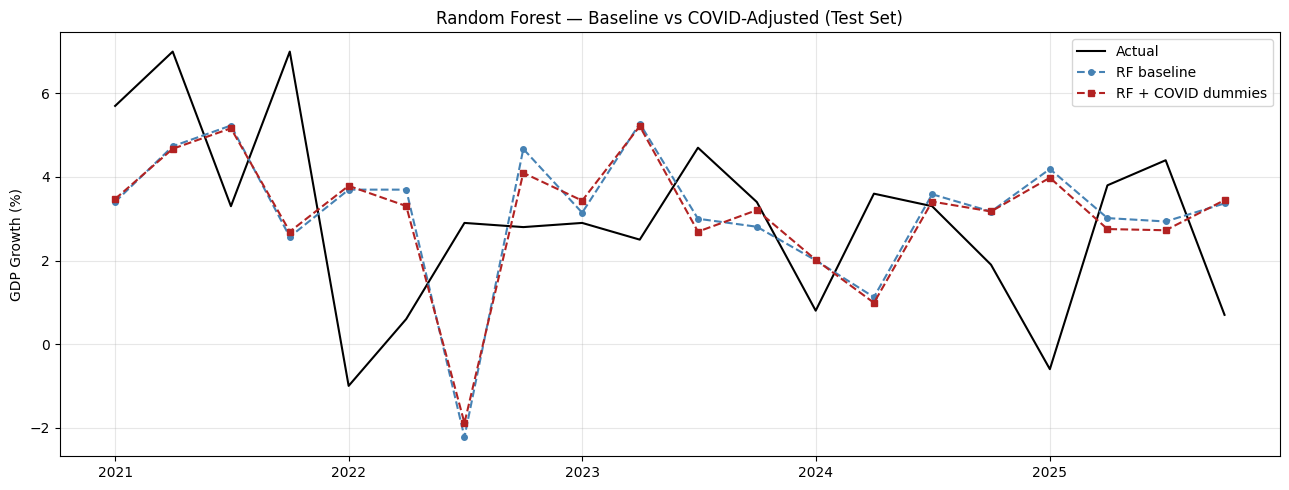

In [11]:
# ── 9. Visualisation — baseline vs COVID-adjusted predictions ────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(dates_test_c, y_test_c,       label='Actual',             color='black',     linewidth=1.5)
ax.plot(dates_test_c, y_pred_test,    label='RF baseline',        color='steelblue', linestyle='--', marker='o', markersize=4)
ax.plot(dates_test_c, y_pred_test_c,  label='RF + COVID dummies', color='firebrick', linestyle='--', marker='s', markersize=4)
ax.set_title('Random Forest — Baseline vs COVID-Adjusted (Test Set)')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()